In [123]:
import pandas as pd
data = pd.read_csv("sauto_dataset.csv", sep=',')


data.loc[data["pohon"].isna(), "pohon"] = "nezadano"
# maska_ke_smazani = (data['palivo'] == 'elektro') & ((data['kapacita baterie'] == 0) | (data['kapacita baterie'].isna()))
# data = data[~maska_ke_smazani]

indexy_elektro = data[(data['palivo'] == 'Elektro') & (data['kapacita_baterie'] == 0)].index
indexy_none = data[(data['znacka'].isna()) | (data['model'].isna()) | (data['cena'].isna()) | (data['rok'].isna()) | (data['stav'].isna()) | (data['najeto'].isna()) | (data['vykon'].isna()) | (data['palivo'].isna()) | (data['prevodovka'].isna())].index

vsechny_ke_smazani = indexy_elektro.union(indexy_none)
# vsechny_ke_smazani = indexy_elektro
data = data.drop(vsechny_ke_smazani)



string_features = ['znacka', 'model', 'stav', 'palivo', 'prevodovka', 'pohon']
mapping = {}
for feature in string_features:
    data[feature] = data[feature].astype('category')
    mapping[feature] = list(data[feature].cat.categories)
    data[feature] = data[feature].cat.codes

# Jak zjistím, co je co?
# print(mapping['znacka'])
print(mapping['stav'])
print(mapping['palivo'])
print(mapping['prevodovka'])
print(mapping['pohon'])

kod = mapping["znacka"].index('Tesla')
print(f"znacka: ",kod)
kod = mapping["model"].index('Model 3')
print(f"model: ",kod)




# maska = (data["palivo"] == "Elektro") & (data["kapacita_baterie"] == 0)
# print(data[maska])# data

# kokot = (data["palivo"] == "Elektro")
# print(data[kokot])
# print(data["znacka"].unique())

data


['Nové', 'Ojeté', 'Předváděcí']
['Benzín', 'CNG + benzín', 'Elektro', 'Hybridní', 'LPG + benzín', 'Nafta']
['Automatická', 'Manuální', 'Poloautomatická']
['4x4', 'Pohon předních kol', 'Pohon zadních kol', 'nezadano']
znacka:  65
model:  364


,znacka,model,cena,rok,stav,najeto,vykon,palivo,kapacita_baterie,prevodovka,pohon
0,69,509,340000.0,2016.0,1,228069,140.0,5,0,0,3
1,16,201,180000.0,2017.0,1,149609,80.0,5,0,1,0
2,69,386,100000.0,2010.0,1,211625,77.0,0,0,1,3
4,45,545,899000.0,2021.0,1,95000,162.0,5,0,0,3
5,67,525,460000.0,2018.0,1,145317,110.0,5,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...
9463,26,620,265000.0,2020.0,1,168530,85.0,5,0,0,1
9464,23,326,420000.0,2020.0,1,108758,110.0,0,0,1,1
9465,67,272,229000.0,2015.0,1,200450,135.0,5,0,1,1
9466,26,541,355000.0,2016.0,1,59230,130.0,0,0,1,1


In [96]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.tree import DecisionTreeRegressor




input_features = ["znacka", "model", "rok", "stav", "najeto", "vykon", "palivo", "kapacita_baterie", "prevodovka", "pohon"]
target_feature = 'cena'

X_train, X_test, y_train, y_test = train_test_split(data[input_features], data[target_feature], test_size=0.1)
# X_train vstupni trenovaci
# X_test vystupni trenovaci
# y_test vstupni testovaci
# y_train vustupni testovaci


model = DecisionTreeRegressor(max_depth=70)
model.fit(X_train, y_train)



y_pred = model.predict(X_test)


In [107]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(mae)
print(mse)

227400.8299882629
580616706483.1825


In [59]:
y_pred

array([ 3391988.10204082,  4314116.01408451,  5212656.16516517,
        5212656.16516517,   627588.94497937,    37987.32563025,
         111191.68016194,    37987.32563025,   608179.67013889,
         608179.67013889,    37987.32563025,   562119.19607843,
         348347.4567757 ,    37987.32563025,   174582.5620915 ,
         348347.4567757 ,  5212656.16516517,  1721727.27272727,
         608179.67013889,  4314116.01408451,    37987.32563025,
        1033773.58490566,   111191.68016194,   627588.94497937,
          37987.32563025,  5212656.16516517,  5212656.16516517,
         627588.94497937,  1201908.84615385,   700856.7826087 ,
         897956.        ,  3286941.8121547 ,   348347.4567757 ,
        5212656.16516517,   111191.68016194,   608179.67013889,
          37987.32563025,   627588.94497937,   627588.94497937,
        1993148.62222222,   174582.5620915 ,   348347.4567757 ,
         627588.94497937,   174582.5620915 ,   627588.94497937,
       11258825.88888889,  4314116.01408

In [60]:
y_test

3039    2149000.0
4147    3811500.0
3620    7499000.0
4350    3349999.0
701      450000.0
          ...    
5500     254990.0
5268     315000.0
4922     800000.0
4643     110000.0
4455    3199000.0
Name: cena, Length: 568, dtype: float64

In [106]:
from sklearn.tree import export_text
tree_rules = export_text(model, feature_names=input_features)
print(tree_rules)


|--- vykon <= 379.00
|   |--- vykon <= 241.50
|   |   |--- rok <= 2022.50
|   |   |   |--- rok <= 2014.50
|   |   |   |   |--- rok <= 2010.50
|   |   |   |   |   |--- vykon <= 104.50
|   |   |   |   |   |   |--- rok <= 2009.50
|   |   |   |   |   |   |   |--- znacka <= 9.00
|   |   |   |   |   |   |   |   |--- vykon <= 87.50
|   |   |   |   |   |   |   |   |   |--- model <= 298.00
|   |   |   |   |   |   |   |   |   |   |--- rok <= 2003.00
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |   |   |   |   |   |   |   |--- rok >  2003.00
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 4
|   |   |   |   |   |   |   |   |   |--- model >  298.00
|   |   |   |   |   |   |   |   |   |   |--- palivo <= 2.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 7
|   |   |   |   |   |   |   |   |   |   |--- palivo >  2.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |  

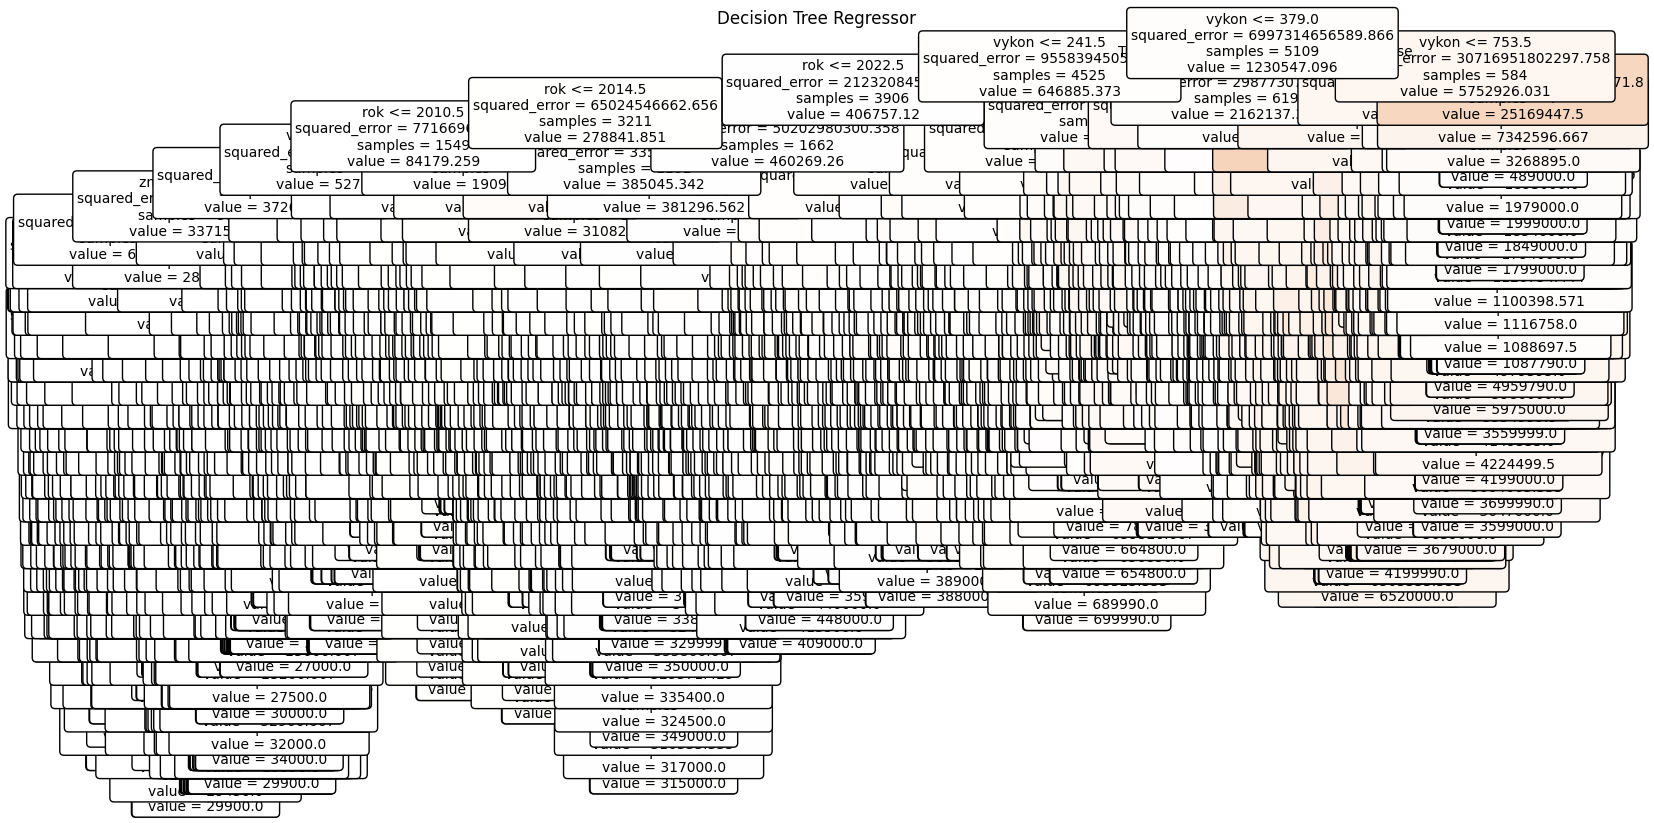

In [105]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(18, 10))
plot_tree(
    model,
    feature_names=input_features,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Regressor")
plt.show()

In [21]:
print(model.tree_.threshold)

[ 4.91499996e+01  2.01650000e+03  2.01250000e+03  2.00950000e+03
  3.77999992e+01  2.00750000e+03 -2.00000000e+00 -2.00000000e+00
  2.00650000e+03 -2.00000000e+00 -2.00000000e+00  4.75000000e+01
  2.01150000e+03 -2.00000000e+00 -2.00000000e+00 -2.00000000e+00
  2.01550000e+03  3.18510000e+04  3.08870000e+04 -2.00000000e+00
 -2.00000000e+00  1.05000000e+01 -2.00000000e+00 -2.00000000e+00
  4.67500000e+01  4.19499989e+01 -2.00000000e+00 -2.00000000e+00
  8.00000000e+00 -2.00000000e+00 -2.00000000e+00  1.80000001e+00
  4.51999989e+01  5.00000000e-01  4.12000008e+01 -2.00000000e+00
 -2.00000000e+00  4.01000004e+01 -2.00000000e+00 -2.00000000e+00
  1.55000001e+00  1.50000000e+00 -2.00000000e+00 -2.00000000e+00
  1.36050000e+03 -2.00000000e+00 -2.00000000e+00  2.01850000e+03
  4.25000000e+01  3.97820000e+04 -2.00000000e+00 -2.00000000e+00
  2.41120000e+04 -2.00000000e+00 -2.00000000e+00  4.50000000e+00
  4.18500004e+01 -2.00000000e+00 -2.00000000e+00  7.00000000e+00
 -2.00000000e+00 -2.00000

In [111]:
import pickle

with open("model_sauto.dat", "wb") as soubor:
     pickle.dump(model, soubor)